# <font color='gray' size=7> Data Science HW </font>


作業完成後至Google表單上傳檔案 https://docs.google.com/forms/d/1YcJB9Na5uVIXRPfG7x9oefmqYe6EZL9T8vM7EuxCtfM/edit
<br>作業繳交期限：4/4 23:55</br>
<br>上傳作業之ipynb檔案，檔名固定為[學號-姓名.ipynb]，例：107379999-王大明.ipynb，未符合格式者將斟酌扣分</br>

---

In [ ]:
import numpy as np
import pandas as pd
import sklearn
Taipei_temp = [23.2, 23.4, 23.3, 22.7, 23.2, 23.4, 23.5, 23.8, 24, 23.9]
Taipei_temp = pd.DataFrame(data=Taipei_temp,columns=['Taipei_temp'])
Taipei_temp

,Taipei_temp
0,23.2
1,23.4
2,23.3
3,22.7
4,23.2
5,23.4
6,23.5
7,23.8
8,24.0
9,23.9


### 範例，對台北天氣做正規化
手刻正規化公式 x' = (x - X_min) / (X_max - X_min)

In [ ]:
range_ = np.max(Taipei_temp) - np.min(Taipei_temp)
Taipei = (Taipei_temp - np.min(Taipei_temp)) / range_
Taipei

,Taipei_temp
0,0.384615
1,0.538462
2,0.461538
3,0.000000
4,0.384615
5,0.538462
6,0.615385
7,0.846154
8,1.000000
9,0.923077


### 第一題，對台北天氣做標準化(20分)
#### 手刻標準化公式 x' = (x - μ)／σ         

同學教學

In [ ]:
Taipei_std = (Taipei_temp - np.mean(Taipei_temp)) / np.std(Taipei_temp, ddof=1)
Taipei_std 

,Taipei_temp
0,-0.621059
1,-0.103510
2,-0.362284
3,-1.914932
4,-0.621059
5,-0.103510
6,0.155265
7,0.931589
8,1.449138
9,1.190363


手刻標準化公式 x' = (x - μ)／σ(網路找)

In [ ]:
mu = np.mean(Taipei_temp,axis=0)
sigma=np.std(Taipei_temp,axis=0)
(Taipei_temp-mu)/sigma

,Taipei_temp
0,-0.654654
1,-0.109109
2,-0.381881
3,-2.018515
4,-0.654654
5,-0.109109
6,0.163663
7,0.981981
8,1.527525
9,1.254753


硬算

In [ ]:
μ=(23.2+23.4+23.3+22.7+23.2+23.4+23.5+23.8+24+23.9)/10
print(μ)

23.44


In [ ]:
σ=10-1
print(σ)

9


In [ ]:
a=(Taipei_temp-μ)/σ
print(a)

   Taipei_temp
0    -0.026667
1    -0.004444
2    -0.015556
3    -0.082222
4    -0.026667
5    -0.004444
6     0.006667
7     0.040000
8     0.062222
9     0.051111


### 第二題 資料格式轉換及補值
l = [1, 3, np.nan, 5, 4,10,np.nan,8,6,2] 
#### 2.1 請將上方list轉成dataframe格式，並且欄位名稱命名為"Number"(20分)


同學教學

In [ ]:
lData = [1, 3, np.nan, 5, 4, 10, np.nan, 8, 6, 2]
lData = pd.DataFrame(data=lData,columns=['Number'])
lData

,Number
0,1.0
1,3.0
2,NaN
3,5.0
4,4.0
5,10.0
6,NaN
7,8.0
8,6.0
9,2.0


網路找

In [ ]:
from pandas.core.frame import DataFrame
l = [1, 3, np.nan, 5, 4,10,np.nan,8,6,2]
data=DataFrame(l)
data.rename(columns={0:'Number'},inplace=True)
print(data)

   Number
0     1.0
1     3.0
2     NaN
3     5.0
4     4.0
5    10.0
6     NaN
7     8.0
8     6.0
9     2.0


#### 2.2 使用平均對空值補值(20分)

同學教學

In [ ]:
lData['Number'] = lData['Number'].fillna(lData['Number'].mean())
lData

,Number
0,1.000
1,3.000
2,4.875
3,5.000
4,4.000
5,10.000
6,4.875
7,8.000
8,6.000
9,2.000


網路找

In [ ]:
# 用平均填充
from pandas.core.frame import DataFrame
l= [1, 3, np.nan, 5, 4,10,np.nan,8,6,2]
data=DataFrame(l)
data.rename(columns={0:'Number'},inplace=True)
#fill all Nan value with zero
data= data.fillna(4.875)
print(data)

   Number
0   1.000
1   3.000
2   4.875
3   5.000
4   4.000
5  10.000
6   4.875
7   8.000
8   6.000
9   2.000


In [ ]:
data.describe()

,Number
count,10.000000
mean,4.875000
std,2.684834
min,1.000000
25%,3.250000
50%,4.875000
75%,5.750000
max,10.000000


In [ ]:
data.isnull().sum()

Number    0
dtype: int64

### 第三題 離群值可視化及剃除離群值
資料如下

In [ ]:
from sklearn.datasets import load_boston

boston = load_boston()
x = boston.data
y = boston.target
columns = boston.feature_names
#create the dataframe
boston_df = pd.DataFrame(x)
boston_df.columns = columns
boston_df  #13個特徵，506筆房產資料

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48


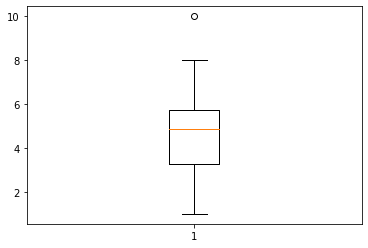

In [ ]:
import matplotlib.pyplot as plt
for col in data.iloc[:,0:4]: #data.columns[0:4]
    plt.boxplot(x=data[col], sym ="o", whis = 1.5)
    plt.show()

In [ ]:
#for col in data.iloc[:,0:4]: #data.columns[0:4]
    #plt.boxplot(x=data[col], sym ="o", whis = 1.5)
    #plt.show()

#### 3.1請撰寫迴圈畫出波士頓房產資料集各欄位之盒鬚圖(20分)

模仿教材


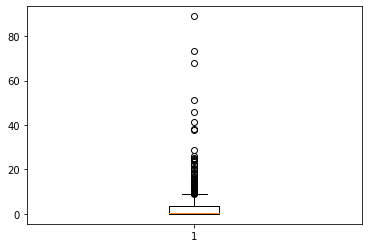

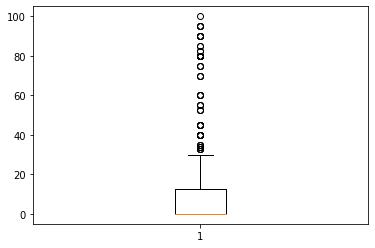

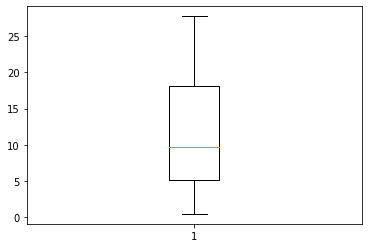

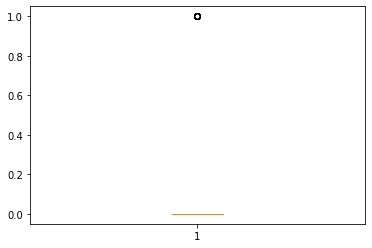

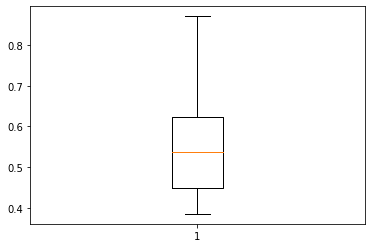

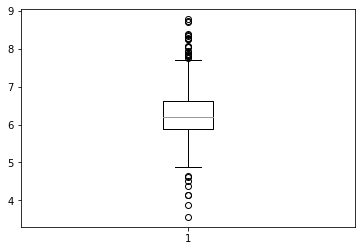

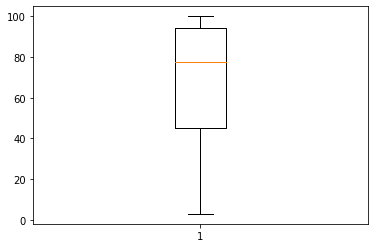

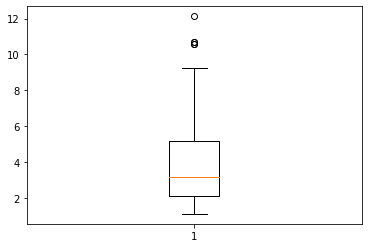

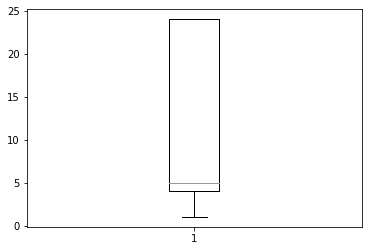

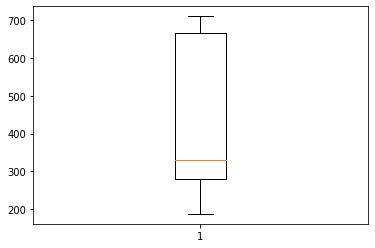

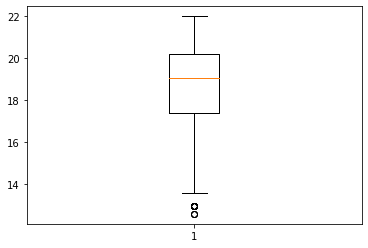

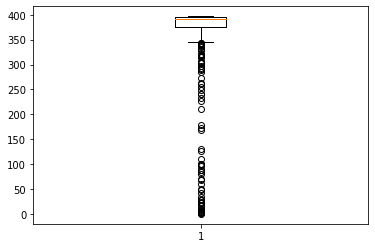

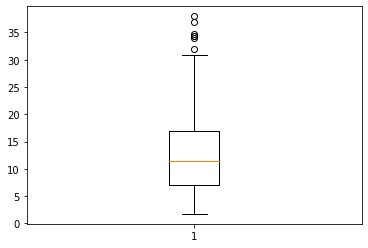

In [ ]:
import matplotlib.pyplot as plt #506rows × 13 columns
for col in boston_df.iloc[:,0:13]:
    plt.boxplot(x=boston_df[col], sym ="o", whis = 1.5)
    plt.show()

根據常態分布的經驗法則，有 99.7% 的觀測值落在母體平均值正負 3 個母體標準差的範圍內。因此，假設收集到的資料符合常態分佈的假設，若觀測值落在樣本平均值正負 3 個樣本標準差以外的數值，可判定該觀測值屬於離群值。

#### 3.2請撰寫程式剔除/篩選欄位「CRIM」超過3個標準差的值(20分)

In [ ]:
CRIM_zValue = (boston_df['CRIM'] - np.mean(boston_df['CRIM'])) / np.std(boston_df['CRIM'], ddof=1)
CRIM_zValue

0     -0.419367
1     -0.416927
2     -0.416929
3     -0.416338
4     -0.412074
         ...   
501   -0.412820
502   -0.414839
503   -0.413038
504   -0.407361
505   -0.414590
Name: CRIM, Length: 506, dtype: float64

In [ ]:
boston_df["CRIM_zValue"] = CRIM_zValue
mask1 = boston_df["CRIM_zValue"] < 3
mask2 = boston_df["CRIM_zValue"] > -3
boston_df[(mask1 & mask2)] 

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,CRIM_zValue
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,-0.419367
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,-0.416927
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,-0.416929
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,-0.416338
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,-0.412074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,-0.412820
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,-0.414839
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,-0.413038
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,-0.407361
